Question 1: What is a Convolutional Neural Network (CNN), and how does it differ from traditional fully connected neural networks in terms of architecture and performance on image data?

Answer:
A Convolutional Neural Network (CNN) is a type of deep learning model designed specifically to process data with a grid-like topology, such as images. Unlike traditional fully connected (FC) networks, which flatten input images into a single vector, CNNs preserve the spatial structure of data by using local receptive fields and weight sharing.

The key architectural differences include:

Local Connectivity: In FC networks, every neuron in one layer connects to every neuron in the next, which leads to a massive number of parameters for images. CNNs use filters that connect only to a small region of the input, making them more efficient.   
Weight Sharing: In CNNs, the same filter is applied across the entire image, allowing the model to detect the same feature (like an edge) regardless of its position.   
Performance: FC networks are prone to overfitting on image data due to the high parameter count and lack of spatial awareness. CNNs achieve superior performance by automatically learning hierarchical features, such as textures in early layers and complex objects in deeper layers.

Question 2: Discuss the architecture of LeNet-5 and explain how it laid the foundation for modern deep learning models in computer vision. Include references to its original research paper.

Answer:
LeNet-5, introduced by Yann LeCun et al. in the 1998 paper "Gradient-Based Learning Applied to Document Recognition," was the first successful CNN for handwritten digit recognition (MNIST).
Its architecture consists of seven layers:
    C1 (Convolutional Layer): Extracts basic features.   
    S2 (Subsampling/Pooling Layer): Reduces spatial resolution.     
    C3 (Convolutional Layer): Learns complex combinations of features.   
    S4 (Subsampling Layer): Further dimensionality reduction.   
    C5 (Convolutional Layer): Fully connected layer disguised as a convolution.   
    F6 (Fully Connected Layer): Uses tanh activation.   
    Output Layer: Uses Gaussian connections for classification.   

LeNet-5 laid the foundation for modern vision models by establishing the core pattern used today: alternating convolutional and pooling layers followed by fully connected layers for final classification.

Question 3: Compare and contrast AlexNet and VGGNet in terms of design principles, number of parameters, and performance. Highlight key innovations and limitations of each.

Answer:  
AlexNet and VGGNet represent two major milestones in deep learning, differing significantly in their design philosophies. AlexNet, utilizes an architecture of 8 layers with large filters (such as 11x11 and 5x5) to capture spatial features. In contrast, VGGNet (specifically VGG16) introduced a more modular and uniform approach in 2014, favoring a deeper 16-layer stack composed entirely of small 3x3 filters to achieve the same receptive field with more non-linearity.

This increase in depth leads to a substantial difference in complexity; while AlexNet contains approximately 60 million parameters, VGGNet is much heavier with about 138 million parameters. In terms of performance, VGGNet significantly improved upon AlexNet’s error rates, achieving roughly 7.3% top-5 error compared to AlexNet's 15.3%. Key innovations in AlexNet included the first major implementation of ReLU activations, Dropout, and GPU-based training, whereas VGGNet’s main contribution was demonstrating that increasing network depth using small, stacked filters is a critical driver for performance. However, both have limitations: AlexNet is considered shallow by modern standards and uses inefficiently large filters, while VGGNet is notoriously memory-intensive and computationally expensive to train due to its massive parameter count.

Question 4: What is transfer learning in the context of image classification? Explain how it helps in reducing computational costs and improving model performance with limited data.

Answer:  
Transfer learning is a technique where a model developed for one task (e.g., classifying 1,000 objects in ImageNet) is reused as the starting point for a different but related task (e.g., classifying medical X-rays).

Benefits:
Reduced Computational Cost: Instead of training a massive model from scratch, we use pre-trained weights, which requires significantly fewer training epochs and less GPU power.   
Limited Data Handling: Training deep models on small datasets often leads to overfitting. Transfer learning leverages "knowledge" of general features (edges, shapes) from the large dataset, allowing the model to perform well even with only a few hundred images in the target dataset.

Question 5: Describe the role of residual connections in ResNet architecture. How do they address the vanishing gradient problem in deep CNNs?

Answer:  
Residual connections, or "skip connections," allow the input of a layer to bypass one or more layers and be added directly to the output of a later layer. The layer learns a "residual mapping" F(x)=H(x)−x rather than the full underlying mapping H(x).

Vanishing Gradient Solution:
In extremely deep networks, gradients tend to diminish (vanish) as they are backpropagated through many layers, preventing the model from learning. Residual connections create a "highway" for the gradient to flow directly through the identity mapping, ensuring that the gradient remains strong even in networks with hundreds of layers.

Question 6: Implement the LeNet-5 architecture using PyTorch to classify the MNIST dataset.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 1. Define the LeNet-5 Architecture
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        # Feature extraction layers
        self.features = nn.Sequential(
            # Conv1: 1 channel in, 6 out, kernel 5x5, padding 2 makes 28x28 -> 32x32
            nn.Conv2d(1, 6, kernel_size=5, padding=2),
            nn.Tanh(),
            # Pool1: Reduces spatial dims by half (16x16)
            nn.AvgPool2d(kernel_size=2, stride=2),
            # Conv2: 6 channels in, 16 out, kernel 5x5
            nn.Conv2d(6, 16, kernel_size=5),
            nn.Tanh(),
            # Pool2: Reduces spatial dims by half (5x5)
            nn.AvgPool2d(kernel_size=2, stride=2),
        )
        # Classification layers (Fully connected)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 5 * 5, 120),
            nn.Tanh(),
            nn.Linear(120, 84),
            nn.Tanh(),
            nn.Linear(84, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 2. Setup Device and Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Normalize using MNIST mean and std for better training stability
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 3. Initialize Model, Loss, and Optimizer
model = LeNet5().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 4. Training Loop
epochs = 5
for epoch in range(epochs):
    model.train() # Set to training mode
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()        # Clear previous gradients
        outputs = model(images)      # Forward pass
        loss = criterion(outputs, labels) # Calculate loss
        loss.backward()              # Backpropagation
        optimizer.step()             # Update weights

        running_loss += loss.item()

    # 5. Evaluation Loop
    model.eval() # Set to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad(): # Disable gradient calculation for efficiency
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Epoch [{epoch + 1}/{epochs}], Loss: {running_loss / len(train_loader):.4f}, Test Accuracy: {accuracy:.2f}%")

Epoch [1/5], Loss: 0.2487, Test Accuracy: 97.09%
Epoch [2/5], Loss: 0.0704, Test Accuracy: 98.26%
Epoch [3/5], Loss: 0.0504, Test Accuracy: 98.52%
Epoch [4/5], Loss: 0.0380, Test Accuracy: 98.66%
Epoch [5/5], Loss: 0.0311, Test Accuracy: 98.20%


Same Implementation using tensorflow(for my practise)  
Training LeNet-5 on the MNIST dataset is a classic deep learning project. Since MNIST images are
and the original LeNet-5 architecture expects
, you'll need to pad the images or adjust the input layer.
1. Load and Preprocess Data
Load the dataset directly from TensorFlow Keras Datasets . You must reshape the data to include the single grayscale channel and normalize the pixel values to a
range

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

# Load MNIST
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Reshape to (60000, 28, 28, 1) and normalize
train_images = train_images.reshape((60000, 28, 28, 1)).astype('float32') / 255
test_images = test_images.reshape((10000, 28, 28, 1)).astype('float32') / 255

# Optional: Pad to 32x32 to match original LeNet-5 exactly
train_images = tf.pad(train_images, [[0, 0], [2, 2], [2, 2], [0, 0]])
test_images = tf.pad(test_images, [[0, 0], [2, 2], [2, 2], [0, 0]])

2. Build the LeNet-5 Model
LeNet-5 uses two sets of Convolutional and Average Pooling layers, followed by three Fully Connected (Dense) layers.

In [ ]:
model = models.Sequential([
    # Layer 1: Conv2D (6 filters, 5x5) + AveragePooling
    layers.Conv2D(6, kernel_size=(5, 5), activation='tanh', input_shape=(32, 32, 1)),
    layers.AveragePooling2D(pool_size=(2, 2)),

    # Layer 2: Conv2D (16 filters, 5x5) + AveragePooling
    layers.Conv2D(16, kernel_size=(5, 5), activation='tanh'),
    layers.AveragePooling2D(pool_size=(2, 2)),

    # Flatten and Fully Connected Layers
    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

3. Compile and Train
Use sparse_categorical_crossentropy if your labels are integers (0-9) to avoid needing manual one-hot encoding.

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train for ~10-20 epochs
model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_split=0.1)

# Evaluate on test data
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {test_acc:.4f}")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.9177 - loss: 0.2797 - val_accuracy: 0.9685 - val_loss: 0.1091
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9673 - loss: 0.1056 - val_accuracy: 0.9770 - val_loss: 0.0762
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9780 - loss: 0.0702 - val_accuracy: 0.9807 - val_loss: 0.0726
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9837 - loss: 0.0527 - val_accuracy: 0.9802 - val_loss: 0.0678
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9878 - loss: 0.0405 - val_accuracy: 0.9803 - val_loss: 0.0668
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9894 - loss: 0.0342 - val_accuracy: 0.9833 - val_loss: 0.0568
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.9913 - loss: 0.0283 - val_accuracy: 0.9840 - val_loss: 0.0579
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9927 - loss: 0.0230 - val

Question 7: Use a pre-trained VGG16 model on a small custom dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input

2026-05-01 20:35:10.411313: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777667710.602132      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777667710.655261      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777667711.092749      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777667711.092803      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777667711.092806      57 computation_placer.cc:177] computation placer alr

In [ ]:
data_dir = "/kaggle/input/datasets/imbikramsaha/caltech-101/caltech-101/"
img_size = (224, 224)
batch_size = 32

In [ ]:
# 2. Load dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Improve pipeline performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 9144 files belonging to 102 classes.
Using 7316 files for training.


I0000 00:00:1777667748.996062      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 9144 files belonging to 102 classes.
Using 1828 files for validation.


In [ ]:
# 3. Build model
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze VGG16 layers
base_model.trainable = False

# Data augmentation for small datasets
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

In [ ]:
# 4. Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# 5. Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


I0000 00:00:1777667769.759644     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


229/229 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.2959 - loss: 4.0761 - val_accuracy: 0.6734 - val_loss: 1.3175
Epoch 2/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.6427 - loss: 1.4167 - val_accuracy: 0.7916 - val_loss: 0.8107
Epoch 3/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.7451 - loss: 0.9596 - val_accuracy: 0.8217 - val_loss: 0.6629
Epoch 4/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step - accuracy: 0.7915 - loss: 0.7450 - val_accuracy: 0.8496 - val_loss: 0.5821
Epoch 5/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.8197 - loss: 0.6476 - val_accuracy: 0.8600 - val_loss: 0.5589
Epoch 6/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.8422 - loss: 0.5394 - val_accuracy: 0.8643 - val_loss: 0.5583
Epoch 7/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.8577 - loss: 0.4927 - val_accuracy: 0.8649 - val_loss: 0.5822
Epoch 8/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 20s 86ms/step - accuracy: 0.8785 - loss: 0.4295 - val_accurac

In [ ]:
# 6. Evaluate model
loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")

58/58 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.8665 - loss: 0.5787
Validation Accuracy: 0.8725


Question 8: Write a program to visualize the filters and feature maps of the first convolutional layer of AlexNet.

c:\Users\Tatha\anaconda3\envs\pwskills\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Tatha\anaconda3\envs\pwskills\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


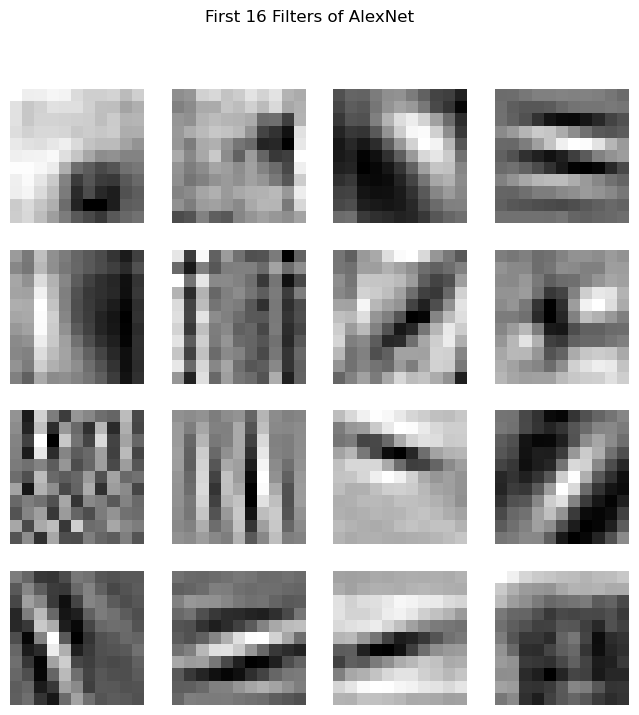

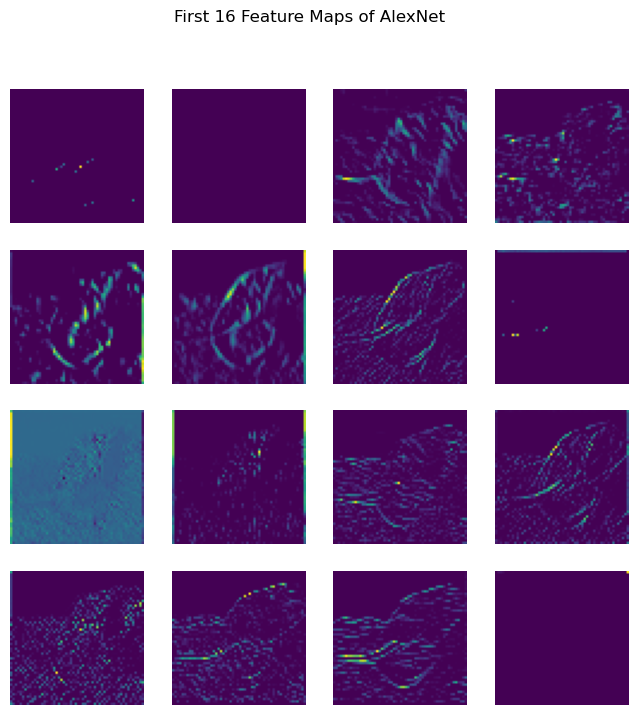

In [ ]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load pre-trained AlexNet
model = models.alexnet(pretrained=True)
model.eval() # Set to evaluation mode

# Access the first convolutional layer (features[0])
conv1 = model.features[0]
weights = conv1.weight.data

# 2. Visualize First 16 Filters
# Weights shape: (96, 3, 11, 11) -> (out_channels, in_channels, height, width)
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(16):
    # Visualize the first input channel (R channel)
    ax = axes.flat[i]
    ax.imshow(weights[i][0].cpu(), cmap='gray')
    ax.axis('off')
plt.suptitle("First 16 Filters of AlexNet")
plt.show()

# 3. Visualize First 16 Feature Maps
# Prepare a sample image
img = Image.open('data/elephant.jpg').convert('RGB')
preprocess = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
])
input_tensor = preprocess(img).unsqueeze(0) # Add batch dimension

# Hook the first layer to extract its output
feature_maps = None
def hook_fn(module, input, output):
    global feature_maps
    feature_maps = output

handle = conv1.register_forward_hook(hook_fn)
model(input_tensor)
handle.remove() # Remove hook after use

# Visualize 16 feature maps
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i in range(16):
    ax = axes.flat[i]
    # Squeeze batch dim and detach from graph
    ax.imshow(feature_maps[0, i].detach().cpu(), cmap='viridis')
    ax.axis('off')
plt.suptitle("First 16 Feature Maps of AlexNet")
plt.show()

Question 9: Train a GoogLeNet (Inception v1) using CIFAR-10.

In [3]:
import tarfile
import os

data_root = './data'
archive_path = os.path.join(data_root, 'cifar-10-python.tar.gz')

# Create the data directory if it doesn't exist
os.makedirs(data_root, exist_ok=True)

# Check if the archive exists and extract it
if os.path.exists(archive_path):
    print(f"Extracting {archive_path}...")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=data_root)
    print("Extraction complete.")
else:
    print(f"Archive not found at {archive_path}. Please ensure it is uploaded.")



Extracting ./data/cifar-10-python.tar.gz...


/tmp/ipykernel_1438/4009100869.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=data_root)


Extraction complete.


In [4]:
import torch, torch.nn as nn, torch.optim as optim, torchvision as tv
from torchvision import transforms, models

# 1. Prepare Data
trans = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = tv.datasets.CIFAR10(root='./data', train=True, download=False, transform=trans)
test_set = tv.datasets.CIFAR10(root='./data', train=False, download=False, transform=trans)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)

# 2. Setup Model
model = models.googlenet(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

# 3. Train
crit, opt = nn.CrossEntropyLoss(), optim.Adam(model.parameters(), lr=0.001)
model.train()
for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    opt.zero_grad()
    crit(model(images), labels).backward()
    opt.step()

# 4. Evaluate (The part you were missing)
model.eval()
correct = total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        _, pred = torch.max(model(images), 1)
        total += labels.size(0)
        correct += (pred == labels).sum().item()

print(f"Final Test Accuracy: {100 * correct / total:.2f}%")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=GoogLeNet_Weights.IMAGENET1K_V1`. You can also use `weights=GoogLeNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 82.4MB/s]


Final Test Accuracy: 84.02%


Question 10: You are working in a healthcare AI startup. Your team is tasked with
developing a system that automatically classifies medical X-ray images into normal,
pneumonia, and COVID-19. Due to limited labeled data, what approach would you
suggest using among CNN architectures discussed (e.g., transfer learning with ResNet
or Inception variants)? Justify your approach and outline a deployment strategy for
production use.

Answer:
Proposed Approach:
I suggest using Transfer Learning with ResNet-50.   

Justification:

Limited Data: Pre-training on ImageNet allows the model to understand basic features, requiring only fine-tuning on the X-ray data.   
Accuracy: Residual connections in ResNet prevent performance degradation, which is critical for medical accuracy.   
Efficiency: ResNet-50 provides a strong balance between depth and computational speed compared to larger models like VGG19.   

Deployment Strategy:   

Pre-processing: Implement strict normalization and CLAHE (Contrast Limited Adaptive Histogram Equalization) to standardize X-ray quality.   
API Integration: Wrap the model in a FastAPI or Flask container for real-time inference.   
Human-in-the-loop: The system should provide a confidence score; any low-confidence classification must be flagged for manual radiologist review.